# HeritageNet — Model & Data Dashboard

Simple, reliable (matplotlib only) — no extra packages needed. Live-computed from the
champion model. Adds metrics about **the dataset** and **the model's output**.

**Run: Restart & Run All.**

Sections: headline metrics · dataset composition · per-class F1 · precision & recall ·
F1 vs data size · confusion matrix · most-confused pairs · confidence · threshold trade-off ·
strategy comparison.

In [1]:
# 1 · Setup ------------------------------------------------------------
import os
if os.path.basename(os.getcwd())=="notebooks": os.chdir("..")
import numpy as np, torch
import torch.nn.functional as F
from collections import Counter
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.metrics import (accuracy_score,f1_score,precision_score,
                             recall_score,confusion_matrix)
from heritagenet.data.datamodule import HeritageDataModule
from heritagenet.models.factory import build_model
from heritagenet.utils.device import get_device
%matplotlib inline

# clean LIGHT theme
plt.rcParams.update({
    'figure.dpi':110,'figure.facecolor':'white','axes.facecolor':'#faf8f5',
    'axes.edgecolor':'#d9d4cc','axes.labelcolor':'#33404d','text.color':'#243b53',
    'xtick.color':'#627d98','ytick.color':'#627d98','axes.titlecolor':'#243b53',
    'font.size':10,'axes.grid':True,'grid.color':'#eae6df','grid.alpha':.9,
    'axes.spines.top':False,'axes.spines.right':False,'font.family':'DejaVu Sans'})
TEAL='#1f8a80';CORAL='#e8663d';GOLD='#e2a63b';PLUM='#7b5ea7';SUB='#627d98'
def qcolor(v): return '#d64545' if v<0.6 else '#e8813a' if v<0.75 else GOLD if v<0.9 else TEAL

CKPT='checkpoints/phase2_86acc_FINAL.pt'; MODEL='mobilenet_v3_small'
device=get_device()
dm=HeritageDataModule(root='data',batch_size=32).setup(); classes=dm.classes
nice=[c.replace('_',' ') for c in classes]
model=build_model(MODEL,num_classes=dm.num_classes,pretrained=False,freeze_backbone=False)
st=torch.load(CKPT,map_location=device); model.load_state_dict(st.get('model_state',st))
model.to(device).eval()
print(f'loaded {CKPT} | {dm.num_classes} classes')

loaded checkpoints/phase2_86acc_FINAL.pt | 26 classes


In [2]:
# predictions + counts -------------------------------------------------
loader=DataLoader(dm.test_dataset,batch_size=32,shuffle=False,num_workers=0)
Pr=[]; y_true=[]
with torch.no_grad():
    for imgs,lbls in loader:
        Pr.append(F.softmax(model(imgs.to(device)),1).cpu()); y_true+=lbls.tolist()
probs=torch.cat(Pr).numpy(); y_true=np.array(y_true); y_pred=probs.argmax(1)
pred_conf=probs.max(1)
prec=precision_score(y_true,y_pred,average=None,zero_division=0)
rec =recall_score(y_true,y_pred,average=None,zero_division=0)
f1c =f1_score(y_true,y_pred,average=None,zero_division=0)
tr=Counter(dm.train_dataset.targets); va=Counter(dm.val_dataset.targets); te=Counter(dm.test_dataset.targets)
n_tr=np.array([tr[i] for i in range(dm.num_classes)])
n_va=np.array([va[i] for i in range(dm.num_classes)])
n_te=np.array([te[i] for i in range(dm.num_classes)])
print(f'test images: {len(y_true)} | total dataset: {n_tr.sum()+n_va.sum()+n_te.sum()}')

test images: 179 | total dataset: 1044


## 2 · Headline metrics

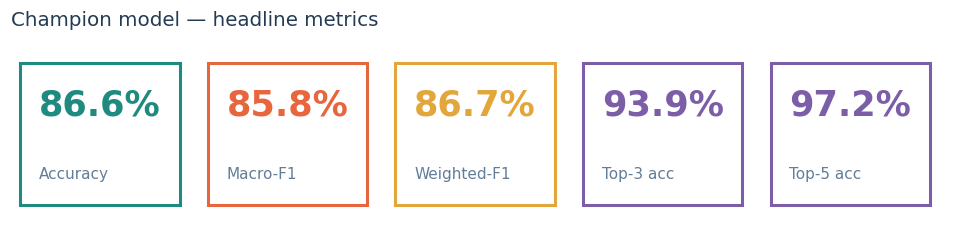

accuracy 0.866 · macro-F1 0.858 · weighted-F1 0.867 · top-3 0.939 · top-5 0.972
macro vs weighted gap 0.8 pts — how much thin classes drag the fair metric down


In [3]:
acc=accuracy_score(y_true,y_pred);mf1=f1_score(y_true,y_pred,average='macro')
wf1=f1_score(y_true,y_pred,average='weighted')
def topk(pr,y,k): tk=np.argsort(pr,1)[:,-k:]; return np.mean([y[i] in tk[i] for i in range(len(y))])
t3=topk(probs,y_true,3); t5=topk(probs,y_true,5)
cards=[('Accuracy',acc,TEAL),('Macro-F1',mf1,CORAL),('Weighted-F1',wf1,GOLD),
       ('Top-3 acc',t3,PLUM),('Top-5 acc',t5,PLUM)]
fig,ax=plt.subplots(figsize=(11,2.2)); ax.axis('off')
for i,(l,v,c) in enumerate(cards):
    x=i/len(cards)
    ax.add_patch(plt.Rectangle((x+.01,.12),1/len(cards)-.03,.76,transform=ax.transAxes,
        facecolor='white',edgecolor=c,lw=2))
    ax.text(x+.03,.60,f'{v:.1%}',transform=ax.transAxes,fontsize=23,fontweight='bold',color=c)
    ax.text(x+.03,.26,l,transform=ax.transAxes,fontsize=10,color=SUB)
ax.set_title('Champion model — headline metrics',loc='left',fontsize=13,pad=10); plt.show()
print(f'accuracy {acc:.3f} · macro-F1 {mf1:.3f} · weighted-F1 {wf1:.3f} · top-3 {t3:.3f} · top-5 {t5:.3f}')
print(f'macro vs weighted gap {abs(wf1-mf1)*100:.1f} pts — how much thin classes drag the fair metric down')

## 3 · Dataset composition — how much data per site
Tells the story of the data itself: which sites are well-sampled and which are thin.

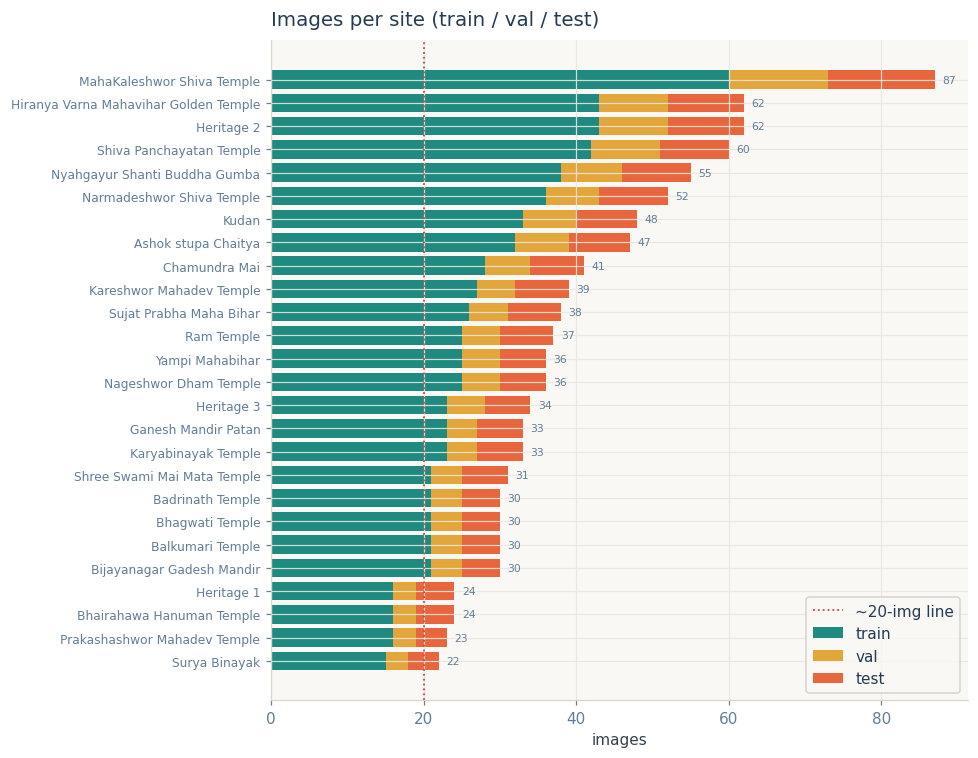

most photos: MahaKaleshwor Shiva Temple (87) · fewest: Surya Binayak (22)


In [4]:
order=np.argsort(n_tr+n_va+n_te)
idx=np.arange(dm.num_classes)
fig,ax=plt.subplots(figsize=(9,7))
ax.barh(idx,n_tr[order],color=TEAL,label='train')
ax.barh(idx,n_va[order],left=n_tr[order],color=GOLD,label='val')
ax.barh(idx,n_te[order],left=n_tr[order]+n_va[order],color=CORAL,label='test')
ax.set_yticks(idx); ax.set_yticklabels([nice[i] for i in order],fontsize=8)
ax.axvline(20,color='#d64545',ls=':',lw=1.2,label='~20-img line')
ax.set_xlabel('images'); ax.legend(loc='lower right')
ax.set_title('Images per site (train / val / test)',loc='left',fontsize=13,pad=10)
for i,o in enumerate(order):
    t=n_tr[o]+n_va[o]+n_te[o]; ax.text(t+1,i,str(t),va='center',fontsize=7,color=SUB)
plt.tight_layout(); plt.show()
print(f'most photos: {nice[order[-1]]} ({(n_tr+n_va+n_te)[order[-1]]}) · '
      f'fewest: {nice[order[0]]} ({(n_tr+n_va+n_te)[order[0]]})')

## 4 · Per-class F1 — sorted worst → best

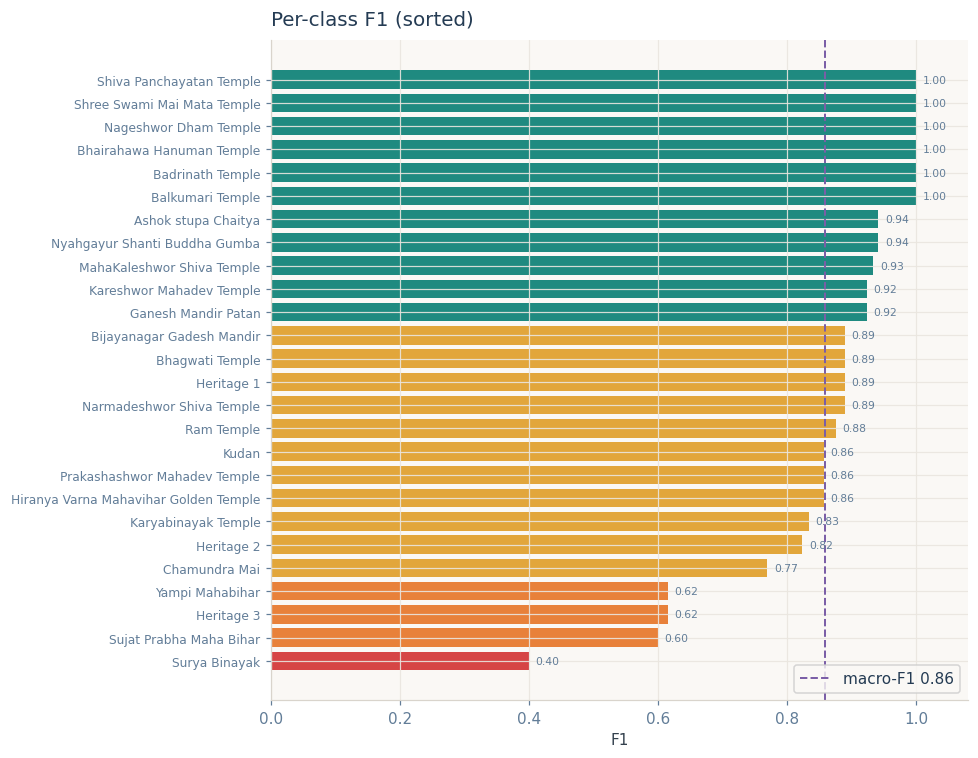

In [5]:
o=np.argsort(f1c)
fig,ax=plt.subplots(figsize=(9,7))
ax.barh(range(dm.num_classes),[f1c[i] for i in o],color=[qcolor(f1c[i]) for i in o])
ax.set_yticks(range(dm.num_classes)); ax.set_yticklabels([nice[i] for i in o],fontsize=8)
ax.axvline(mf1,color=PLUM,ls='--',lw=1.3,label=f'macro-F1 {mf1:.2f}')
ax.set_xlabel('F1'); ax.set_xlim(0,1.08); ax.legend(loc='lower right')
ax.set_title('Per-class F1 (sorted)',loc='left',fontsize=13,pad=10)
for i,ix in enumerate(o): ax.text(f1c[ix]+.01,i,f'{f1c[ix]:.2f}',va='center',fontsize=7,color=SUB)
plt.tight_layout(); plt.show()

## 5 · Precision vs Recall per site
Precision = "when it says site X, is it right?"  Recall = "does it catch all of site X's photos?" 

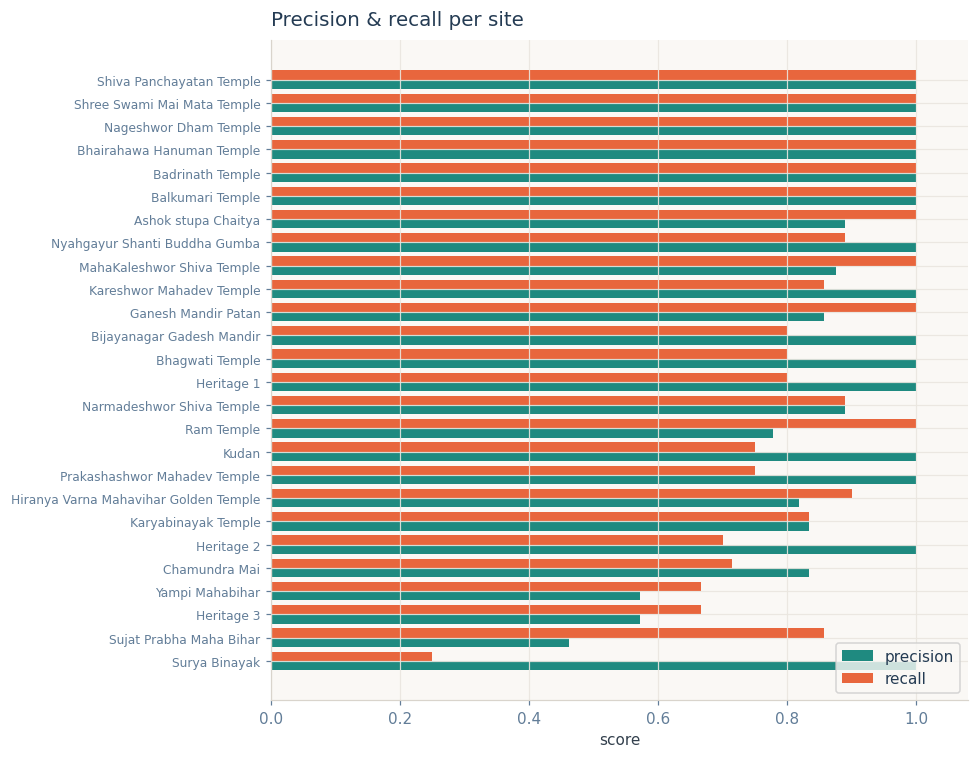

In [6]:
o=np.argsort(f1c)
y=np.arange(dm.num_classes); h=0.4
fig,ax=plt.subplots(figsize=(9,7))
ax.barh(y-h/2,[prec[i] for i in o],h,color=TEAL,label='precision')
ax.barh(y+h/2,[rec[i] for i in o],h,color=CORAL,label='recall')
ax.set_yticks(y); ax.set_yticklabels([nice[i] for i in o],fontsize=8)
ax.set_xlabel('score'); ax.set_xlim(0,1.08); ax.legend(loc='lower right')
ax.set_title('Precision & recall per site',loc='left',fontsize=13,pad=10)
plt.tight_layout(); plt.show()

## 6 · F1 vs training-set size — the *data-limited* evidence
Weak sites clustering at low photo counts ⇒ the limit is **data quantity**, not the model.

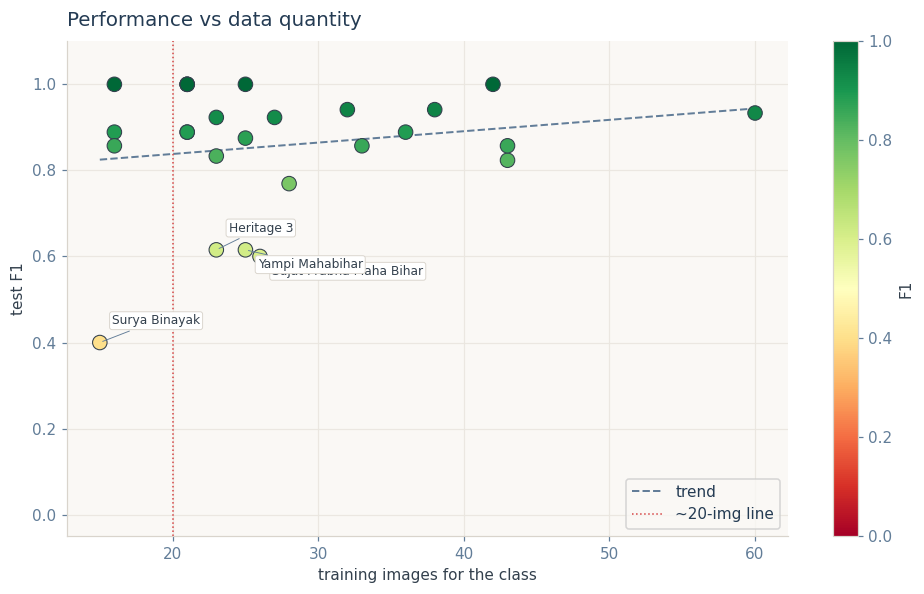

correlation(F1, training size) = 0.19 (positive ⇒ more data → higher F1)


In [7]:
fig,ax=plt.subplots(figsize=(9,5.5))
sc=ax.scatter(n_tr,f1c,s=90,c=f1c,cmap='RdYlGn',vmin=0,vmax=1,edgecolor='#33404d',lw=.7,zorder=3)
z=np.polyfit(n_tr,f1c,1); xs=np.linspace(n_tr.min(),n_tr.max(),50)
ax.plot(xs,np.poly1d(z)(xs),color=SUB,ls='--',lw=1.3,label='trend')
ax.axvline(20,color='#d64545',ls=':',lw=1,label='~20-img line')
# label only the weak tail to avoid overlap; slight vertical offsets
weak=[i for i in range(dm.num_classes) if f1c[i]<0.72]
for j,i in enumerate(sorted(weak,key=lambda k:f1c[k])):
    ax.annotate(nice[i],(n_tr[i],f1c[i]),fontsize=8,color='#33404d',
                xytext=(8,(-1)**j*12),textcoords='offset points',
                arrowprops=dict(arrowstyle='-',color=SUB,lw=.6),
                bbox=dict(boxstyle='round,pad=0.2',fc='white',ec='#d9d4cc',lw=.6))
ax.set_xlabel('training images for the class'); ax.set_ylabel('test F1')
ax.set_ylim(-.05,1.1); ax.legend(loc='lower right')
ax.set_title('Performance vs data quantity',loc='left',fontsize=13,pad=10)
plt.colorbar(sc,label='F1'); plt.tight_layout(); plt.show()
print(f'correlation(F1, training size) = {np.corrcoef(n_tr,f1c)[0,1]:.2f} (positive ⇒ more data → higher F1)')

## 7 · Confusion matrix (row-normalized)

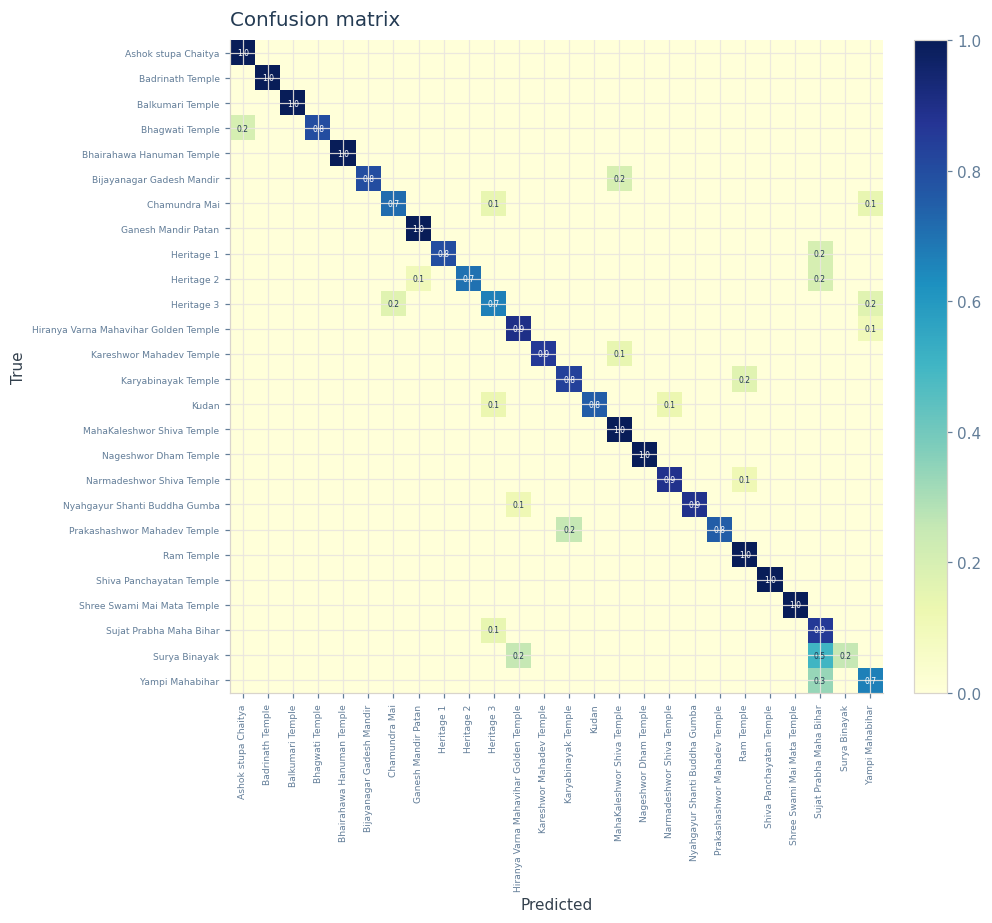

In [8]:
cm=confusion_matrix(y_true,y_pred,labels=range(dm.num_classes))
cmn=np.nan_to_num(cm/cm.sum(1,keepdims=True))
fig,ax=plt.subplots(figsize=(9.5,8.5))
im=ax.imshow(cmn,cmap='YlGnBu',vmin=0,vmax=1)
ax.set_xticks(range(dm.num_classes)); ax.set_yticks(range(dm.num_classes))
ax.set_xticklabels(nice,rotation=90,fontsize=6); ax.set_yticklabels(nice,fontsize=6)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(dm.num_classes):
    for j in range(dm.num_classes):
        if cmn[i,j]>=0.10:
            ax.text(j,i,f'{cmn[i,j]:.1f}',ha='center',va='center',fontsize=5,
                    color='white' if cmn[i,j]>0.5 else '#243b53')
ax.set_title('Confusion matrix',loc='left',fontsize=13,pad=10)
plt.colorbar(im,fraction=.046,pad=.04); plt.tight_layout(); plt.show()

## 8 · Most-confused pairs
The specific mistakes the model makes most — where to focus data collection next.

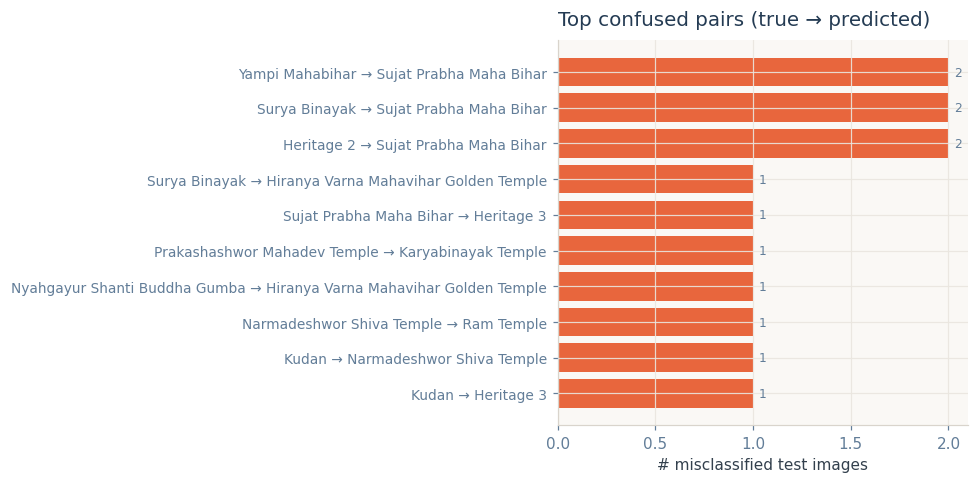

In [9]:
pairs=[]
for i in range(dm.num_classes):
    for j in range(dm.num_classes):
        if i!=j and cm[i,j]>0: pairs.append((cm[i,j],nice[i],nice[j]))
pairs.sort(reverse=True); top=pairs[:10]
if top:
    fig,ax=plt.subplots(figsize=(9,4.5))
    lbl=[f'{t} → {p}' for _,t,p in top]
    ax.barh(range(len(top)),[c for c,_,_ in top],color=CORAL)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(lbl,fontsize=9)
    ax.invert_yaxis(); ax.set_xlabel('# misclassified test images')
    ax.set_title('Top confused pairs (true → predicted)',loc='left',fontsize=13,pad=10)
    for i,(c,_,_) in enumerate(top): ax.text(c+.03,i,str(c),va='center',fontsize=8,color=SUB)
    plt.tight_layout(); plt.show()
else:
    print('no confusions — perfect classification')

## 9 · Confidence — correct vs wrong predictions
Does the model get less confident when it's wrong? (Useful for an "I don't know" threshold.)

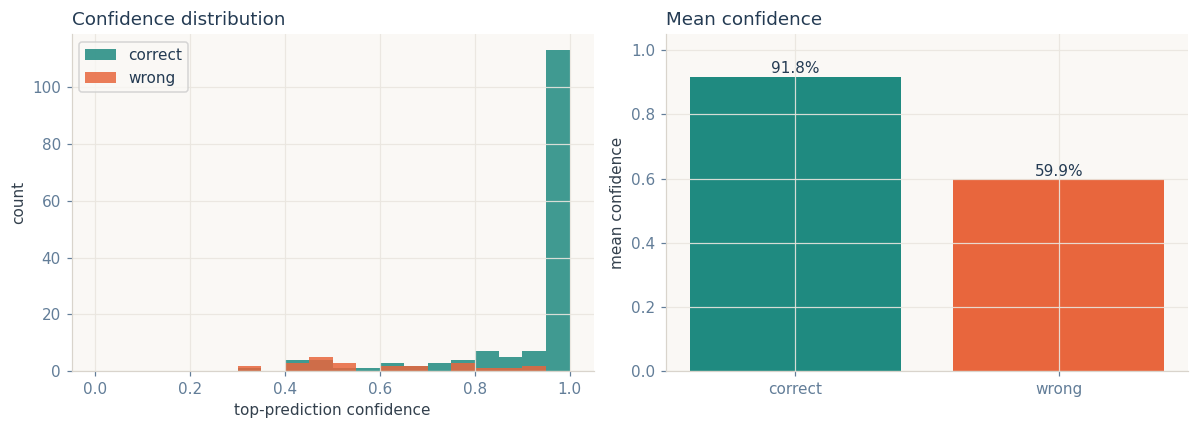

mean confidence — correct 91.8% · wrong 59.9%


In [10]:
correct=y_true==y_pred
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].hist(pred_conf[correct],bins=20,range=(0,1),color=TEAL,alpha=.85,label='correct')
ax[0].hist(pred_conf[~correct],bins=20,range=(0,1),color=CORAL,alpha=.85,label='wrong')
ax[0].set_xlabel('top-prediction confidence'); ax[0].set_ylabel('count'); ax[0].legend()
ax[0].set_title('Confidence distribution',loc='left',fontsize=12)
mc,mw=pred_conf[correct].mean(),(pred_conf[~correct].mean() if (~correct).any() else 0)
ax[1].bar(['correct','wrong'],[mc,mw],color=[TEAL,CORAL])
for i,v in enumerate([mc,mw]): ax[1].text(i,v+.01,f'{v:.1%}',ha='center',color='#243b53')
ax[1].set_ylim(0,1.05); ax[1].set_ylabel('mean confidence')
ax[1].set_title('Mean confidence',loc='left',fontsize=12)
plt.tight_layout(); plt.show()
print(f'mean confidence — correct {mc:.1%} · wrong {mw:.1%}')

## 10 · Selective prediction — the "I don't know" trade-off
Answer only when confidence ≥ threshold: coverage (how much it answers) vs accuracy on what it answers.

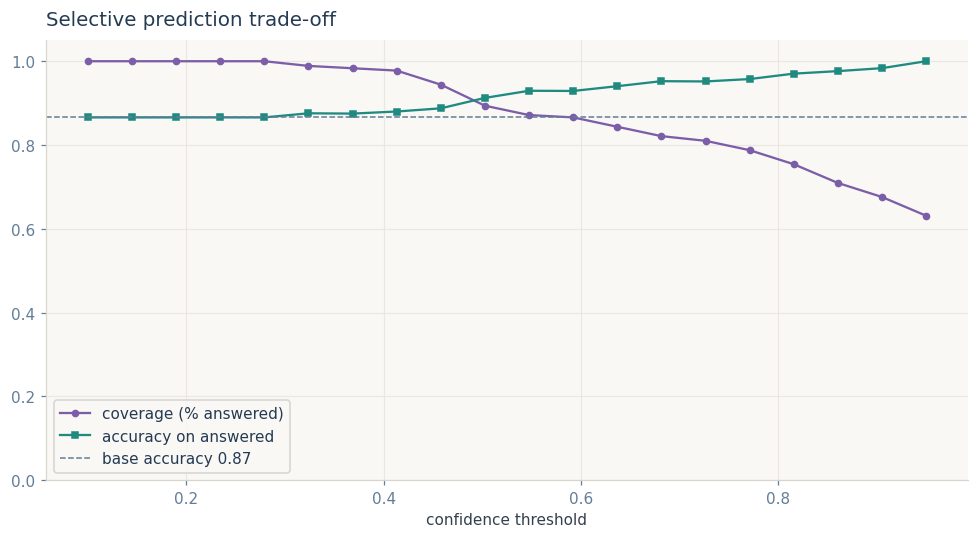

In [11]:
ths=np.linspace(0.1,0.95,20); cov=[]; sa=[]
for t in ths:
    k=pred_conf>=t; cov.append(k.mean())
    sa.append(accuracy_score(y_true[k],y_pred[k]) if k.any() else np.nan)
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(ths,cov,'-o',color=PLUM,label='coverage (% answered)',ms=4)
ax.plot(ths,sa,'-s',color=TEAL,label='accuracy on answered',ms=4)
ax.axhline(acc,color=SUB,ls='--',lw=1,label=f'base accuracy {acc:.2f}')
ax.set_xlabel('confidence threshold'); ax.set_ylim(0,1.05); ax.legend(loc='lower left')
ax.set_title('Selective prediction trade-off',loc='left',fontsize=13,pad=10)
plt.tight_layout(); plt.show()

## 11 · Fine-tuning strategy comparison

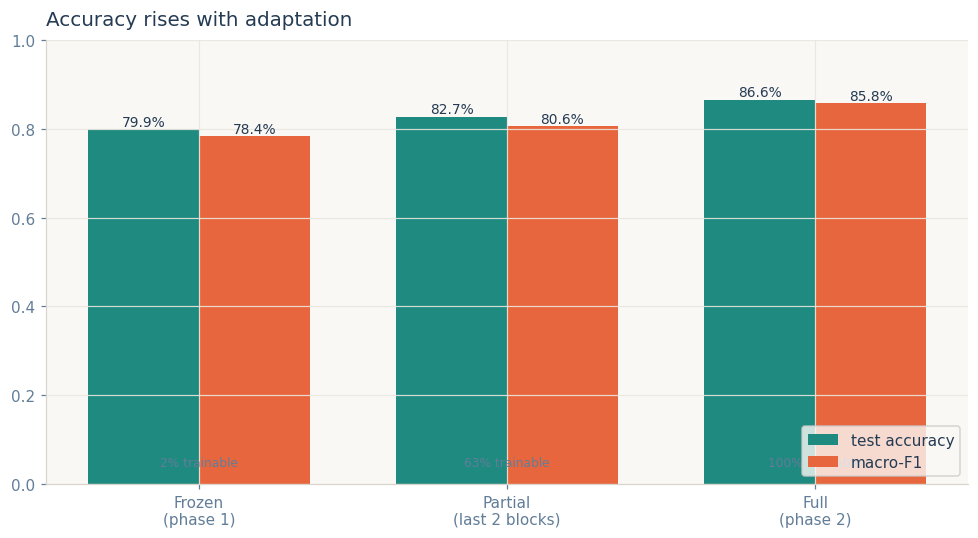

In [12]:
strat=['Frozen\n(phase 1)','Partial\n(last 2 blocks)','Full\n(phase 2)']
acc_s=[0.799,0.827,0.866]; f1_s=[0.784,0.806,0.858]; tp=[1.7,62.7,100]
x=np.arange(3); w=.36
fig,ax=plt.subplots(figsize=(9,5))
b1=ax.bar(x-w/2,acc_s,w,color=TEAL,label='test accuracy')
b2=ax.bar(x+w/2,f1_s,w,color=CORAL,label='macro-F1')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+.008,f'{b.get_height():.1%}',
            ha='center',fontsize=9,color='#243b53')
for i,t in enumerate(tp): ax.text(i,.04,f'{t:.0f}% trainable',ha='center',fontsize=8,color=SUB)
ax.set_xticks(x); ax.set_xticklabels(strat); ax.set_ylim(0,1.0); ax.legend(loc='lower right')
ax.set_title('Accuracy rises with adaptation',loc='left',fontsize=13,pad=10)
plt.tight_layout(); plt.show()

---
**How to read this dashboard**
- §2 headline · §3 shows the *data* (thin vs rich sites) · §4–5 per-class output quality
- §6 ties them together: performance tracks data quantity ⇒ **data-limited**
- §7–8 the specific confusions to fix next · §9–10 confidence & "I don't know" behavior
- §11 why full fine-tuning was chosen

*Matplotlib only — no extra packages, renders anywhere.*